# K-means clustering

In [1]:
# Data manipulation / Работа с данными
import pandas as pd
import numpy as np

# Import datasets from sklearn / Импорт наборов данных из sklearn
from sklearn.datasets import fetch_20newsgroups

# Plotting library / Библиотека для визуализации
import matplotlib.pyplot as plt

# Jupyter magic for inline plots / Магия Jupyter для встроенных графиков
%matplotlib inline

# Regular expressions for text cleaning / Регулярные выражения для очистки текста
import re
import string

# NLP libraries for text preprocessing / NLP библиотеки для предобработки текста
from nltk import word_tokenize  # Tokenization / Токенизация
from nltk.corpus import stopwords  # Stop words removal / Удаление стоп-слов
from nltk.stem import WordNetLemmatizer  # Lemmatization / Лемматизация

# Text vectorization / Векторизация текста
from sklearn.feature_extraction.text import TfidfVectorizer

# Counter for frequency analysis / Счетчик для частотного анализа
from collections import Counter

# Plot customization / Настройка графиков
from pylab import *

# Main NLTK library / Основная библиотека NLTK
import nltk

# Suppress warning messages / Подавление предупреждений
import warnings
warnings.filterwarnings('ignore')

# Seaborn for better visualizations / Seaborn для улучшенной визуализации
import seaborn as sns
sns.set()

# Distance computation / Вычисление расстояний
from scipy.spatial.distance import cdist

# K-Means clustering / Кластеризация K-средних
from sklearn.cluster import KMeans

In [2]:
# Download required NLTK resources / Загрузка необходимых ресурсов NLTK
nltk.download('punkt_tab')      # For word_tokenize / Для токенизации
nltk.download('punkt')           # Additional tokenizer data / Дополнительные данные токенизатора
nltk.download('stopwords')       # For stop words / Для стоп-слов
nltk.download('wordnet')         # For lemmatizer / Для лемматизатора

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
stop_words = stopwords.words('english')
stop_words = stop_words + list(string.printable)
lemmatizer = WordNetLemmatizer()

In [4]:
categories= ['misc.forsale', 'sci.electronics', 'talk.religion.misc']
news_data = fetch_20newsgroups(subset='train', categories=categories, \
                               shuffle=True, random_state=42, download_if_missing=True)

In [5]:
news_data_df = pd.DataFrame({'text' : news_data['data'], 'category': news_data.target})
news_data_df.head()

,text,category
0,From: Steve@Busop.cit.wayne.edu (Steve Teolis)...,0
1,From: jks2x@holmes.acc.Virginia.EDU (Jason K. ...,0
2,From: wayne@uva386.schools.virginia.edu (Tony ...,1
3,From: lihan@ccwf.cc.utexas.edu (Bruce G. Bostw...,1
4,From: myoakam@cis.ohio-state.edu (micah r yoak...,0


In [6]:
news_data_df['cleaned_text'] = news_data_df['text'].apply(\
lambda x : ' '.join([lemmatizer.lemmatize(word.lower()) \
    for word in word_tokenize(re.sub(r'([^\s\w]|_)+', ' ', str(x))) if word.lower() not in stop_words]))

In [7]:
tfidf_model = TfidfVectorizer(max_features=200)
tfidf_df = pd.DataFrame(tfidf_model.fit_transform(news_data_df['cleaned_text']).todense())
tfidf_df.columns = sorted(tfidf_model.vocabulary_)
tfidf_df.head()

,00,10,100,12,14,15,16,20,25,30,...,well,wire,wiring,without,word,work,world,would,writes,year
0,0.439108,0.0,0.000000,0.0,0.000000,0.128788,0.137895,0.128562,0.134368,0.0,...,0.0,0.0,0.0,0.0,0.0,0.113938,0.000000,0.000000,0.000000,0.0
1,0.000000,0.0,0.000000,0.0,0.000000,0.294937,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0
2,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0
3,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.142267,0.106317,0.100306,0.0
4,0.000000,0.0,0.207003,0.0,0.191897,0.182138,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0


In [13]:
# Initialize K-Means with 4 clusters and fixed random seed for reproducibility
# Инициализация K-Means с 4 кластерами и фиксированным seed для воспроизводимости
kmeans = KMeans(n_clusters=4, random_state=42)

# Train the model on TF-IDF features / Обучение модели на TF-IDF признаках
kmeans.fit(tfidf_df)

# Predict cluster labels for each document / Предсказание меток кластеров для каждого документа
y_kmeans = kmeans.predict(tfidf_df)

# Store predicted cluster labels in the dataframe / Сохранение меток кластеров в датафрейм
news_data_df['obtained_clusters'] = y_kmeans

In [14]:
# help(KMeans) # So you can look at the documentation

In [15]:
pd.crosstab(news_data_df['category'].replace({0:'misc.forsale', 1:'sci.electronics', 2:'talk.religion.misc'}),\
            news_data_df['obtained_clusters'].replace({0 : 'cluster_1', 1 : 'cluster_2', 2 : 'cluster_3', 3: 'cluster_4'}))

obtained_clusters,cluster_1,cluster_2,cluster_3,cluster_4
category,,,,
misc.forsale,326,160,2,97
sci.electronics,14,135,0,442
talk.religion.misc,0,68,231,78


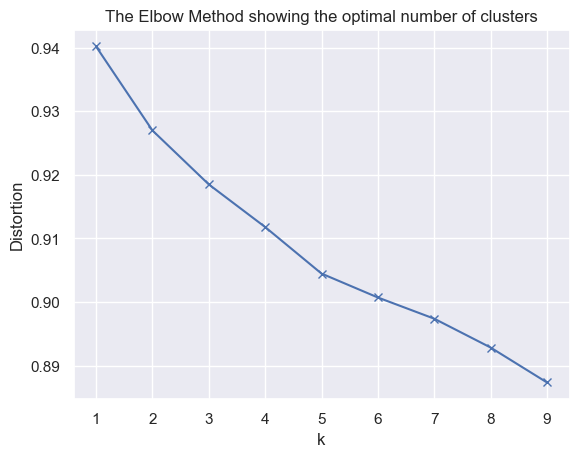

In [16]:
# Using Elbow method to obtain the number of clusters
# Использование метода локтя для определения количества кластеров
distortions = []  # List to store distortion values / Список для хранения значений искажения
K = range(1, 10)  # Try k from 1 to 9 / Пробуем k от 1 до 9

for k in K:
    # Create K-Means model with k clusters / Создание модели K-Means с k кластерами
    kmeanModel = KMeans(n_clusters=k)
    
    # Train the model / Обучение модели
    kmeanModel.fit(tfidf_df)
    
    # Calculate distortion: average distance from points to their cluster centers
    # Вычисление искажения: среднее расстояние от точек до центров их кластеров
    distortions.append(sum(np.min(cdist(tfidf_df, kmeanModel.cluster_centers_, 'euclidean'), \
                                  axis=1)) / tfidf_df.shape[0])

# Plot the elbow / Построение графика локтя
plt.plot(K, distortions, 'bx-')  # 'bx-' = blue markers with line / синие маркеры с линией
plt.xlabel('k')  # Number of clusters / Количество кластеров
plt.ylabel('Distortion')  # Average distance / Среднее расстояние
plt.title('The Elbow Method showing the optimal number of clusters')
plt.show()


# FROM THIS PLOT SELECT K WHERE THE PLOT HAS STEEPEST SLOPE
# Largest drops: k=1→2 and k=4→5
# Suggest k=2 or k=5 as potential optimal values
#
# ИЗ ЭТОГО ГРАФИКА ВЫБЕРИТЕ K, ГДЕ ГРАФИК ИМЕЕТ САМЫЙ КРУТОЙ НАКЛОН
# Самые большие падения: k=1→2 и k=4→5
# Предлагаем k=2 или k=5 как потенциально оптимальные значения

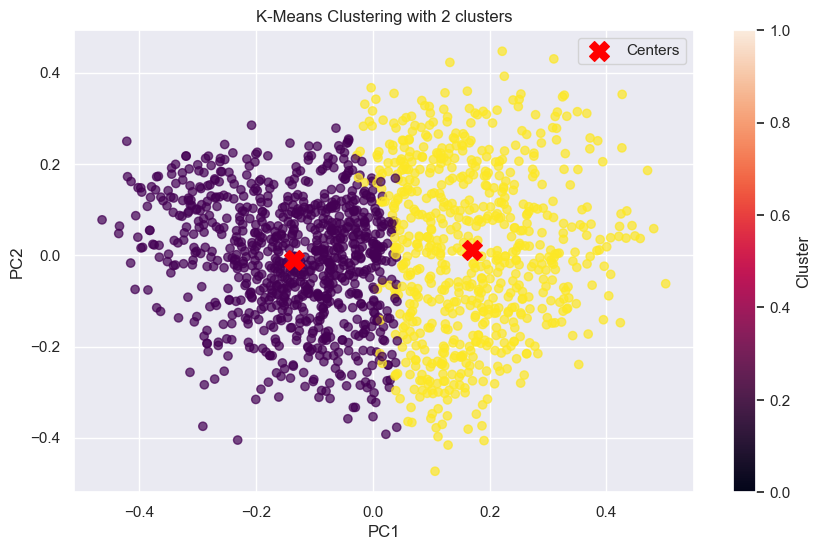

Cluster sizes / Размеры кластеров: [862 691]


In [17]:
from sklearn.decomposition import PCA

# You can experiment with different n_clusters values based on the Elbow curve
# Вы можете попробовать разные значения n_clusters, основываясь на кривой Elbow
n_clusters=2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
y_kmeans = kmeans.fit_predict(tfidf_df)  # fit_predict does both fit and predict

# Reduce to 2D with PCA for visualization / Уменьшаем до 2D с помощью PCA для визуализации
# We might talk about this later, but in this case it will help with visualization.
pca = PCA(n_components=2)
tfidf_2d = pca.fit_transform(tfidf_df)

# Plot clustering results / Визуализация результатов кластеризации
plt.figure(figsize=(10, 6))
plt.scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], c=y_kmeans, cmap='viridis', alpha=0.7)
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0], 
            pca.transform(kmeans.cluster_centers_)[:, 1], 
            c='red', marker='X', s=200, label='Centers')
plt.colorbar(label='Cluster')
plt.title('K-Means Clustering with 2 clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

# Check cluster sizes / Проверка размеров кластеров
print(f"Cluster sizes / Размеры кластеров: {np.bincount(y_kmeans)}")